In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def interp_loglog(df, x_key, y_key):
    """Interpolate y values based on x values in log-log space."""
    mask = (df[y_key].notna()) & (df[x_key].notna())
    df[y_key] = np.power(10, np.interp(
        np.log10(df[x_key]),
        np.log10(df.loc[mask, x_key]),
        np.log10(df.loc[mask, y_key]),
        left=np.nan,
        right=np.nan,
    ))
    return df

def get_runs(proj, filters=None):
    api = wandb.Api()
    runs = api.runs(proj, filters=filters or {}, order="-created_at")
    summary_list, config_list, name_list = [], [], []
    history_list = []
    for run in runs:
        summary_list.append(run.summary._json_dict)
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        config_list.append(config)
        name_list.append(run.name)
        hist = run.history(keys=['student_tokens', 'teacher_tokens', 'distill_kl', 'K(M)_req'])
        eval_hist = run.history(keys=['student_tokens', 'ema_teacher_eval_loss', 'student_eval_loss', 'ema_student_eval_loss', 'K(M)'])
        hist_df = pd.DataFrame(hist)
        eval_hist_df = pd.DataFrame(eval_hist)
        hist_df = hist_df.merge(eval_hist_df, on='student_tokens', how='outer')
        hist_df = hist_df.sort_values('student_tokens').ffill()
        for col in ['ema_teacher_eval_loss', 'student_eval_loss', 'ema_student_eval_loss', 'K(M)']:
            hist_df = interp_loglog(hist_df, 'student_tokens', col)
        hist_df = hist_df.dropna()
        history_list.append(hist_df)
    runs_dict = {"summary": summary_list, "config": config_list, "name": name_list, "history": history_list}
    runs_df = pd.DataFrame(runs_dict)
    runs_df = runs_df[runs_df["summary"].apply(lambda x: x != {})]
    configs = pd.DataFrame.from_dict(list(runs_df['config']))
    cols_that_vary = configs.apply(pd.Series.nunique, axis=0) != 1
    covariates = configs.T[cols_that_vary].T
    runs_df = pd.concat([runs_df, covariates], axis=1)
    runs_df = runs_df.drop(columns=["summary", "config", "name"])
    return runs_df

In [4]:
# Option 1: Load from cached pickle (default)
runs = pd.read_pickle('runs.pkl')

# Option 2: Fetch from wandb (uncomment to re-fetch)
# filters = {
#     'config.tag': 'natural_sweep',
#     'config.T': {"$in": [1000000000, 3000000000, 5000000000]},
#     'config.teacher_ema': 50,
#     'config.max_kl': 0.1,
#     'State': {"$in": ["finished", "running"]},
# }
# runs = get_runs("shikai/soph_jax", filters)
# runs['P_raw'] = runs['P'] * 1e6
# runs = runs[runs['P'].notna()]
# runs = runs[runs['history'].notna()]
# runs.to_pickle('runs.pkl')

print(f'{len(runs)} runs loaded')

452 runs loaded


In [5]:
runs.loc[:, 'history'] = runs['history'].apply(
    lambda hist: pd.DataFrame({k: v for k, v in hist.items()})
)

def set_test_tokens(df, test_tokens, req=True, weight=1):
    df = df.copy(deep=True)
    for idx, row in df.iterrows():
        df.at[idx, 'history'] = row['history'].copy()
        if req:
            df.at[idx, 'history']['K(M)'] = row['history']['K(M)_req'] * 1e6 * weight
            df.at[idx, 'history']['K(X|M)'] = row['history']['ema_student_eval_loss'] * test_tokens / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['student_tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']
        else:
            df.at[idx, 'history']['K(M)'] = row['history']['K(M)'] * 1e6
            df.at[idx, 'history']['K(X|M)'] = row['history']['ema_teacher_eval_loss'] * test_tokens / np.log(2)
            df.at[idx, 'history']['K(M,X)'] = df.at[idx, 'history']['K(M)'] + df.at[idx, 'history']['K(X|M)']
            df.at[idx, 'history']['req_compute'] = 6 * row['P_raw'] * row['history']['teacher_tokens']
            df.at[idx, 'history']['test_compute'] = 2 * row['P_raw'] * test_tokens
            df.at[idx, 'history']['total_compute'] = df.at[idx, 'history']['req_compute'] + df.at[idx, 'history']['test_compute']
    return df

In [6]:
def compute_lower_convex_hull(df, x_key, y_key, tol=0, reduce=None):
    """Compute lower convex hull (minimize both x and y)."""
    all_points = []
    point_to_run_idx = {}
    for run_idx, run in df.iterrows():
        mask = ~np.isnan(run['history'][y_key])
        x_vals = run['history'][x_key][mask].values
        y_vals = run['history'][y_key][mask].values
        for i, (x, y) in enumerate(zip(x_vals, y_vals)):
            all_points.append((x, y))
            point_to_run_idx[(x, y)] = (run_idx, i)
    if len(all_points) < 2:
        return sorted(all_points, key=lambda p: p[0]), point_to_run_idx
    sorted_points = sorted(all_points, key=lambda p: p[0])
    def cross(o, a, b):
        return (a[0] - o[0]) * (b[1] - o[1]) - (a[1] - o[1]) * (b[0] - o[0])
    hull = []
    for point in sorted_points:
        while len(hull) >= 2 and cross(hull[-2], hull[-1], point) <= 0:
            hull.pop()
        if len(hull) > 0:
            min_y_so_far = min(p[1] for p in hull)
            if point[1] - min_y_so_far > tol * max(min_y_so_far, point[1]):
                continue
        hull.append(point)
    if reduce is not None:
        run_to_points = {}
        for point in hull:
            run_idx, _ = point_to_run_idx[point]
            run_to_points.setdefault(run_idx, []).append(point)
        hull = []
        for points in run_to_points.values():
            x_vals = [p[0] for p in points]
            if reduce == 'median':
                selected_idx = np.argmin([abs(x - np.median(x_vals)) for x in x_vals])
            elif reduce == 'min':
                selected_idx = np.argmin(x_vals)
            elif reduce == 'max':
                selected_idx = np.argmax(x_vals)
            else:
                raise ValueError(f"Unknown reduce method: {reduce}")
            hull.append(points[selected_idx])
    return sorted(hull, key=lambda p: p[0]), point_to_run_idx

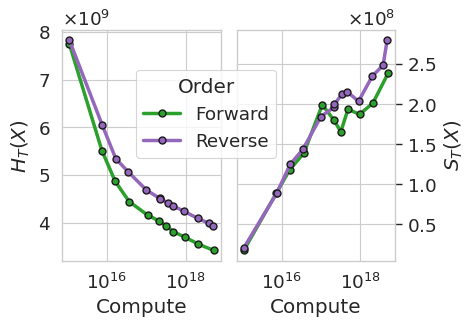

In [7]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

all_datasets = ['chess', 'chess_reordered']
ds_names = {'chess': 'Forward', 'chess_reordered': 'Reverse'}

x_key = 'total_compute'
test_tokens = 5e9
req = True
N = None

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(4.3, 3), sharex=True)

colors = {
    'chess': "#2ca02c",
    'chess_reordered': "#9467bd",
}

global_max_x = 0
for dataset in sorted(all_datasets):
    df_dataset = runs[runs['ds_path'] == dataset]
    df_dataset = set_test_tokens(df_dataset, test_tokens, req)
    for _, run in df_dataset.iterrows():
        mask = ~np.isnan(run['history']['K(M,X)'])
        if mask.any():
            max_x = run['history'][x_key][mask].max()
            global_max_x = max(global_max_x, max_x)

for ds in sorted(all_datasets):
    df_ds = runs[runs['ds_path'] == ds]
    if N is not None:
        df_ds = df_ds[df_ds['N'] == N]
    df_ds = set_test_tokens(df_ds, test_tokens, req)
    color = colors.get(str(ds), "#1f77b4")
    pareto_points, point_to_run_idx = compute_lower_convex_hull(df_ds, x_key, 'K(M,X)', reduce='median')

    for ax, (y_key, y_label) in zip([ax1, ax2], [
        ('K(X|M)', r'$H_T(X)$'),
        ('K(M)', r'$S_T(X)$')
    ]):
        pareto_x, pareto_y = [], []
        for pareto_point in pareto_points:
            run_idx, hist_idx = point_to_run_idx[pareto_point]
            run = df_ds.loc[run_idx]
            mask = ~np.isnan(run['history']['K(M,X)'])
            masked_indices = np.where(mask)[0]
            if hist_idx < len(masked_indices):
                actual_idx = masked_indices[hist_idx]
                pareto_x.append(run['history'][x_key].iloc[actual_idx])
                pareto_y.append(run['history'][y_key].iloc[actual_idx])
        if pareto_x:
            if len(pareto_x) > 100:
                indices = np.linspace(0, len(pareto_x) - 1, 100, dtype=int)
                pareto_x = [pareto_x[i] for i in indices]
                pareto_y = [pareto_y[i] for i in indices]
            ax.plot(pareto_x, pareto_y, c=color, linewidth=2.5,
                    alpha=1, label=f'{ds_names[ds]}', marker='o', markersize=5, mec='k', mew=1)
        ax.set_ylabel(y_label)
        ax.set_xscale('log')

ax1.set_xlabel('Compute')
ax2.set_xlabel('Compute')
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, title='Order', loc='center',
           bbox_to_anchor=(0.46, 0.6), frameon=True)

for ax in [ax1, ax2]:
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    ax.yaxis.set_major_formatter(formatter)

plt.subplots_adjust(wspace=0.1)
plt.show()